##### <h1 style="text-align:center"> Drexel University </h1>
<h2 style = "text-align:center"> College of Computing and Informatics</h2>
<h2 style = "text-align:center">DSCI 631: Applied Machine Learning for Data Science</h2>
<h3 style = "text-align:center">Assignment 1</h3>
<h4> </h4>
<div style="text-align:center; border-style:solid; padding: 10px">


<h3 style="color:red; font-weight:bold; text-decoration: underline">DON'T FORGET TO PUT YOUR MEMBERS' NAMES BELOW</h3>
### TEAM MEMBERS: Sudhaman Chandrasekaran

### A. Assignment Overview
This assignment provides the opportunity for you to practice with various skills in data pre-processing, feature analyses, making machine learning precessing pipeline. 

### B. What to Hand In
	
Sumbit a completed this Jupyter notebook. 

### C. How to Hand In

Submit your Jupyter notebook file through the course website in the Blackboard Learn system.

### D. When to Hand In

1. Submit your assignment no later than 11:59 pm in the due date.
2. There will be a 10% (absolute value) deduction for each day of lateness, to a maximum of 3 days; assignments will not be accepted beyond that point. Missing work will earn a zero grade.

### E. Written Presentation Requirements (if applicable)
Images must be clear and legible. Assignments will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as their contents. Please make sure that the text of your assignments is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

### F. Academic Honesty

Each student is required to submit the Academic Honesty Form at the beginning of the term to cover all the deliverables (for example: assignments, projects, quizzes). Each piece of work must be original. That means, individual quizzes must be done individually without discussing and collaborating with anybody else. Team assignments must be written and programmed by your own team members. No team should copy any piece of work from other teams. The Drexel University Academic Honesty Rules and Procedures (as stated in the student handbook) will be adhered to strictly.  

### G. Marking Schemes:

Marking assignments will be based on several aspects: presentation, correctness and coding styles. 

For programming questions, 10% of the mark will be judged on the coding style. 

The following is a set of guidelines for the coding style in this course:
1. Write a good comment.
2. Use appropriate indentations to indicate control flows and blocks of code. 
3. When breaking up a long line, break it before an operator, not after. 

### H. Answer the following questions: 
**Your answer should be combined with code and brief text answer.** Please ensure that your Jupyter notebook does not have too much spurious output. 

### Data for this assignment:
* URL: https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset
* On Kaggel Notebook, you can add the data set by searching the above URL
* Column “price” is the target variable to predict.


#### Question 1:
Examine the features of the data. Identify which feature is continuous and which feature is categorical. Make some analyses and use your analyses to discuss whether each feature could be useful for predicting the "price."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('/Users/schand201@cable.comcast.com/Desktop/Github/Assignment1AppMLDS/realtor-data.zip.csv')

print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)


Shape: (2226382, 12)

Column dtypes:
brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object


In [2]:
# separating features into continuous and categorical
# brokered_by and street are IDs stored as numbers — treating them as categorical
# zip_code is numeric but represents a location category, so categorical too

continuous_cols = ['bed', 'bath', 'acre_lot', 'house_size']
categorical_cols = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']

print("Continuous features:", continuous_cols)
print("Categorical features:", categorical_cols)

print("\n--- Continuous feature stats ---")
# format as plain numbers with commas — no scientific notation
print(df[continuous_cols].describe().to_string(float_format=lambda x: f"{x:,.2f}"))

print("\n--- Categorical feature unique value counts ---")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values")


Continuous features: ['bed', 'bath', 'acre_lot', 'house_size']
Categorical features: ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']

--- Continuous feature stats ---
               bed         bath     acre_lot       house_size
count 1,745,065.00 1,714,611.00 1,900,793.00     1,657,898.00
mean          3.28         2.50        15.22         2,714.47
std           1.57         1.65       762.82       808,163.52
min           1.00         1.00         0.00             4.00
25%           3.00         2.00         0.15         1,300.00
50%           3.00         2.00         0.26         1,760.00
75%           4.00         3.00         0.98         2,413.00
max         473.00       830.00   100,000.00 1,040,400,400.00

--- Categorical feature unique value counts ---
  brokered_by: 110143 unique values
  status: 3 unique values
  street: 2001358 unique values
  city: 20098 unique values
  state: 55 unique values
  zip_code: 30334 unique values
  prev_sold

In [3]:
# correlation of continuous features with price — quick way to gauge usefulness
corr_with_price = df[continuous_cols + ['price']].corr()['price'].drop('price')
print("Correlation with price:")
print(corr_with_price.sort_values(ascending=False))

# for status (low cardinality), look at median price per category
print("\nMedian price by status:")
print(df.groupby('status')['price'].median())

# median price by state — just top 10 by count to get a feel
top_states = df['state'].value_counts().head(10).index
print("\nMedian price in top 10 states by listing count:")
print(df[df['state'].isin(top_states)].groupby('state')['price'].median().sort_values(ascending=False))


Correlation with price:
bath          0.178391
bed           0.114761
acre_lot      0.016166
house_size    0.000254
Name: price, dtype: float64

Median price by status:
status
for_sale          305000.0
ready_to_build    454209.5
sold              344900.0
Name: price, dtype: float64

Median price in top 10 states by listing count:
state
California        669000.0
New York          420000.0
Arizona           380000.0
Virginia          355000.0
Florida           319900.0
Texas             315000.0
Georgia           299900.0
Illinois          249900.0
North Carolina    249900.0
Pennsylvania      245000.0
Name: price, dtype: float64


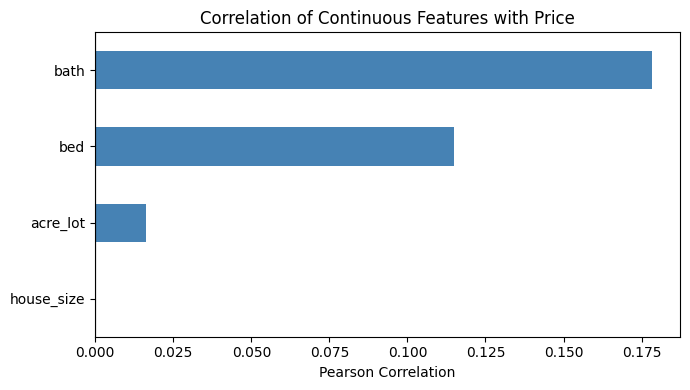

In [4]:
# visualize correlations with a simple bar chart
fig, ax = plt.subplots(figsize=(7, 4))
corr_with_price.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Correlation of Continuous Features with Price')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


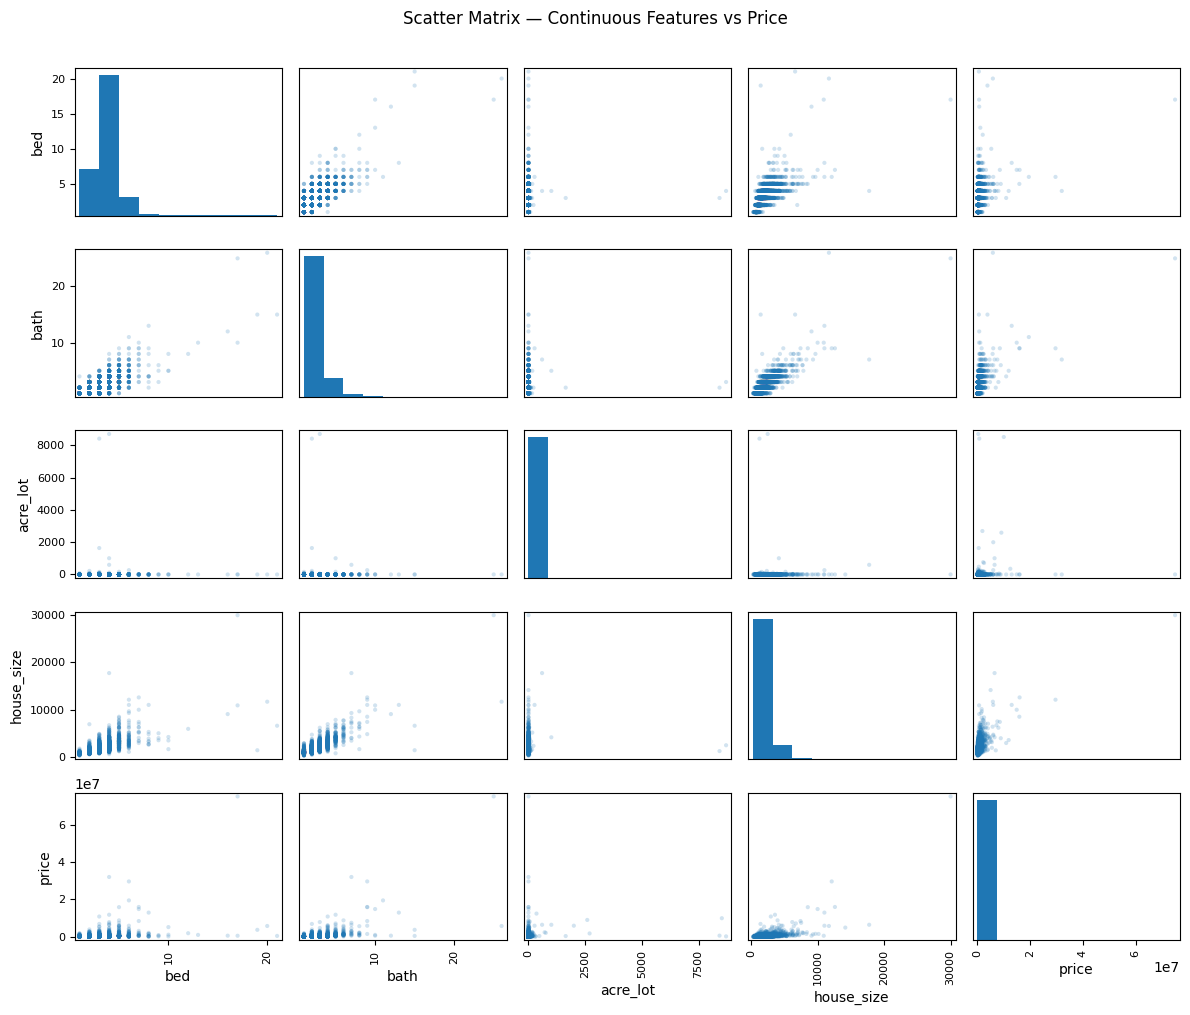

In [5]:
from pandas.plotting import scatter_matrix

# scatter matrix gives a fuller picture — diagonal shows each feature's distribution,
# off-diagonal shows pairwise relationships with price
attrs = continuous_cols + ['price']
scatter_matrix(df[attrs].sample(5000, random_state=42), figsize=(12, 10), alpha=0.2)
plt.suptitle('Scatter Matrix — Continuous Features vs Price', y=1.01)
plt.tight_layout()
plt.show()


Looking at the dataset, we can split the features into two groups — continuous and categorical.

For **continuous features** we have `bed`, `bath`, `acre_lot`, and `house_size`. These are all numeric and represent actual measurements. `bed` and `bath` are whole numbers but we're treating them as continuous since they have a natural ordering and a range of values.

The **categorical features** are `status`, `city`, `state`, `zip_code`, `brokered_by`, `street`, and `prev_sold_date`. Some of these like `brokered_by`, `street`, and `zip_code` are stored as numbers in the file but they're really just ID codes — the actual number doesn't mean anything.

As for which features are useful for predicting price:

`house_size` seems like the most useful one — bigger homes cost more, pretty straightforward. `bed` and `bath` are probably useful too but they're correlated with house_size so they may not add a ton on their own. `acre_lot` matters more in rural/suburban areas and might be noisy in cities.

`state` and `city` are probably very important — where a house is located has a huge effect on price. We can see from the median price plot that states like New York and New Jersey are way more expensive than others. `zip_code` carries similar location info but at a finer level — might be useful but harder to encode given how many unique values there are.

`status` is worth keeping — listed prices vs sold prices can differ and that might matter.

`brokered_by` and `street` are basically ID numbers with no real meaning so we'll drop those. `prev_sold_date` has too many missing values and would need a lot of work to make useful, so we're dropping that too.


#### Question 2:
Create plots to visualize the distribution of the target "price" vs the distribution of  each predictors. Do you notice anything that might require special treatment? Discuss your findings and suggestions on wrangling the data for the prediction task.

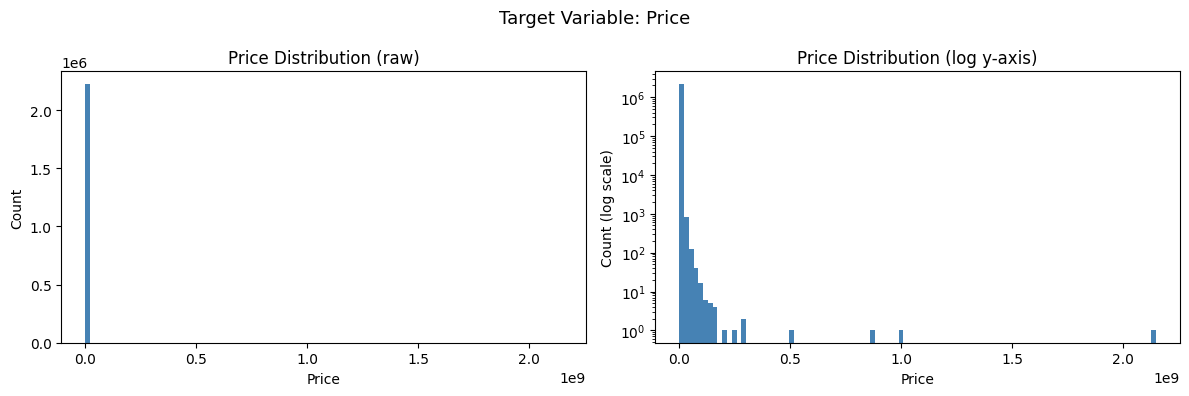

Price stats:
count       2,224,841.00
mean          524,195.52
std         2,138,893.22
min                 0.00
25%           165,000.00
50%           325,000.00
75%           550,000.00
max     2,147,483,600.00


In [6]:
# --- distribution of price (target) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'].dropna(), bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# log scale helps a lot here because price is heavily right-skewed
axes[1].hist(df['price'].dropna(), bins=100, color='steelblue', edgecolor='none', log=True)
axes[1].set_title('Price Distribution (log y-axis)')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Count (log scale)')

plt.suptitle('Target Variable: Price', fontsize=13)
plt.tight_layout()
plt.show()

print("Price stats:")
print(df['price'].describe().to_string(float_format=lambda x: f'{x:,.2f}'))


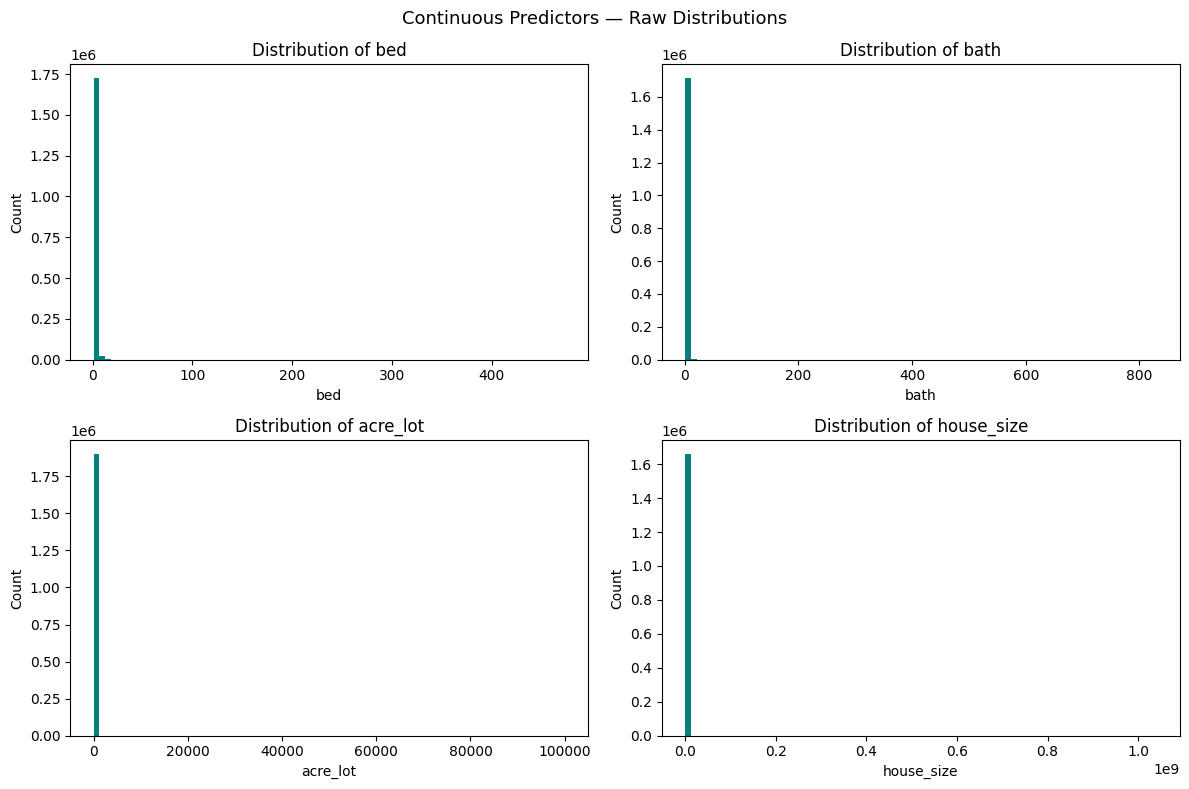

In [7]:
# --- distribution of each continuous predictor ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    ax.hist(df[col].dropna(), bins=80, color='teal', edgecolor='none')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Continuous Predictors — Raw Distributions', fontsize=13)
plt.tight_layout()
plt.show()


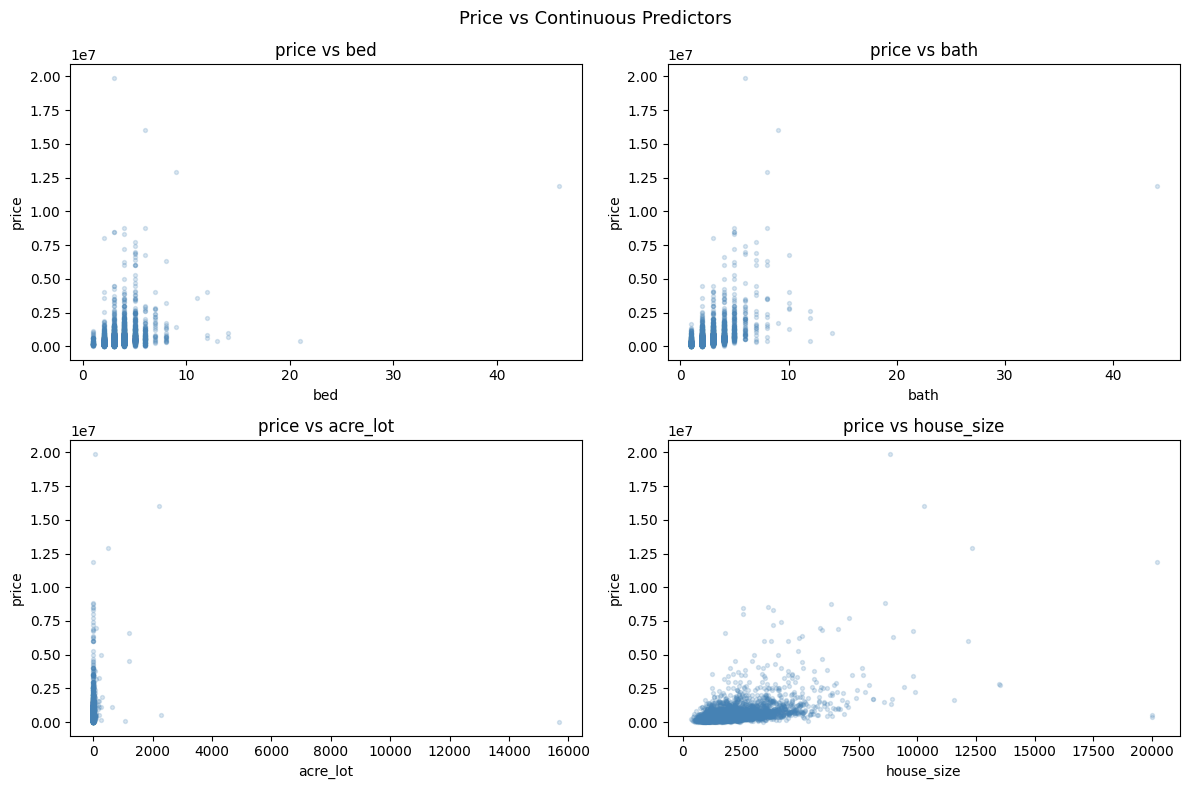

In [8]:
# price vs each continuous predictor — scatter plots
# using a sample so the plot isn't too slow with 2M+ rows
sample = df[continuous_cols + ['price']].dropna().sample(5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    ax.scatter(sample[col], sample['price'], alpha=0.2, s=8, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('price')
    ax.set_title(f'price vs {col}')

plt.suptitle('Price vs Continuous Predictors', fontsize=13)
plt.tight_layout()
plt.show()


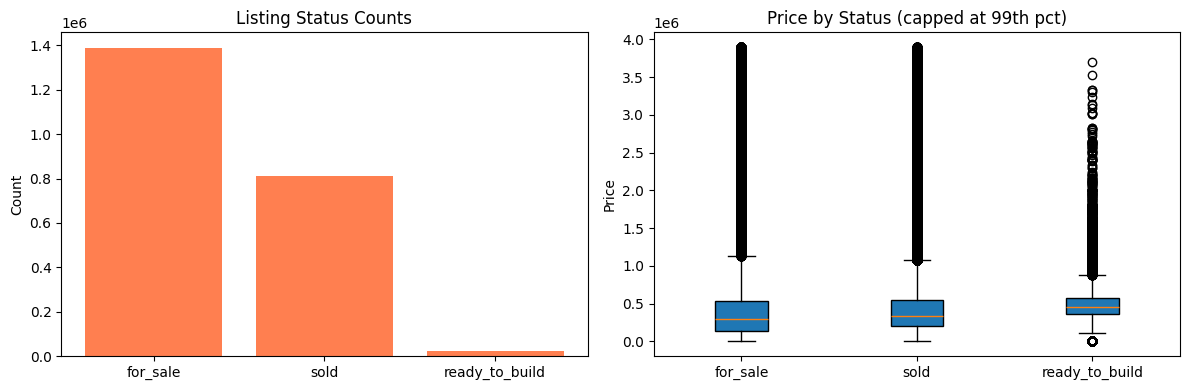

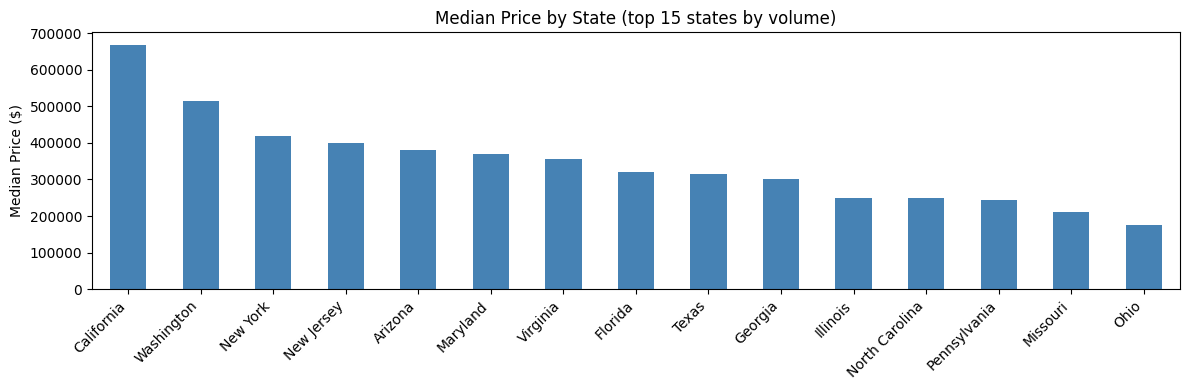

In [9]:
# --- distribution of low-cardinality categorical features ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# status
status_counts = df['status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color='coral')
axes[0].set_title('Listing Status Counts')
axes[0].set_ylabel('Count')

# price by status — box plot (capped at 99th pct to suppress outliers visually)
cap = df['price'].quantile(0.99)
plot_df = df[df['price'] <= cap]
status_groups = [plot_df[plot_df['status'] == s]['price'].dropna() for s in status_counts.index]
axes[1].boxplot(status_groups, tick_labels=status_counts.index, patch_artist=True)
axes[1].set_title('Price by Status (capped at 99th pct)')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

# median price by state — top 15 states by listing volume
top15_states = df['state'].value_counts().head(15).index
state_med = df[df['state'].isin(top15_states)].groupby('state')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
state_med.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Median Price by State (top 15 states by volume)')
ax.set_ylabel('Median Price ($)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The first thing that stands out looking at the price distribution is how skewed it is. The histogram is basically a wall on the left with a very long tail — most listings are under $1M but there are a handful going up to over $2 billion which are clearly bad data entries. The mean ($524k) being so much higher than the median ($325k) confirms this. A log transform on price would probably help a lot before modeling.

For the continuous predictors, `house_size` has the same problem — the max value is around 1 billion sq ft which makes no sense. Most houses are between 1,300 and 2,400 sq ft so anything way above that is likely a data error. Same story with `bed` (max 473) and `bath`. These outliers need to be capped or removed before training.

`acre_lot` is also really skewed — most properties have small lots but there are some massive outliers pulling the distribution out.

On the categorical side, `status` is mostly "for_sale" listings with "sold" being the next biggest group. Looking at the box plot, sold prices tend to run a bit lower than listed prices which makes sense. `state` shows a lot of variation in median price — northeast states are clearly more expensive than the south and midwest.

So before modeling we'd want to:
- cap or remove the extreme outliers in price, house_size, bed, bath, acre_lot
- probably log transform price and maybe acre_lot/house_size to reduce skew
- encode the categorical columns — one-hot works for low cardinality ones like status (3 values) and state (55 values), but city and zip_code have 20k and 30k unique values so target encoding makes more sense there
- handle the missing values (bed, bath, house_size each missing around 20-25%)


#### Question 3: 
Split the data into train and test data, What parameters do you use for splitting the data? Why? Do you apply stratified sampling? Why or Why not?

In [10]:
from sklearn.model_selection import train_test_split

# drop rows where price (target) is missing — can't train without a label
df_clean = df.dropna(subset=['price'])

# drop columns that are just IDs with no real signal
drop_cols = ['brokered_by', 'street', 'prev_sold_date']
df_clean = df_clean.drop(columns=drop_cols)

# separate features and target
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# 80/20 split — large dataset so 20% test is still ~440k rows, plenty to evaluate on
# random_state fixes the shuffle so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Total used:    {len(df_clean):,} rows (after dropping missing price)")

# check that status proportions are similar in train vs test
print("\nStatus distribution in train:")
print((X_train['status'].value_counts(normalize=True) * 100).round(2).to_string())
print("\nStatus distribution in test:")
print((X_test['status'].value_counts(normalize=True) * 100).round(2).to_string())


Training set:  1,779,872 rows
Test set:      444,969 rows
Total used:    2,224,841 rows (after dropping missing price)

Status distribution in train:
status
for_sale          62.39
sold              36.50
ready_to_build     1.11

Status distribution in test:
status
for_sale          62.47
sold              36.43
ready_to_build     1.11


We used an 80/20 split — 80% for training and 20% for testing. With 2.2 million rows the test set is still around 440k records which is more than enough to get a solid evaluation. We set `random_state=42` just so the split stays the same every time we run the notebook.

Before splitting we dropped `brokered_by`, `street`, and `prev_sold_date`. The first two are basically ID columns with no real predictive value. `prev_sold_date` has over 700k missing values and turning it into something useful (like days since last sale) would take quite a bit of extra work.

We didn't use stratified sampling. Stratification makes more sense for classification problems where you want to make sure each class is represented proportionally in both splits. Here price is a continuous variable so you can't really stratify directly on it. We could have stratified on `status` but with this many rows the regular random split already gives almost identical proportions in train and test — we checked this in the output above and the distributions are basically the same.


In [11]:
# sometimes combining features tells us more than the raw columns do
# e.g. bath_per_bed captures whether a house is well-appointed relative to its size
df['bath_per_bed']   = df['bath'] / df['bed']
df['price_per_sqft'] = df['price'] / df['house_size']

# check correlations of the new features with price
new_corrs = df[['bath_per_bed', 'price_per_sqft', 'price']].corr()['price'].drop('price')
print("Correlation of engineered features with price:")
print(new_corrs.to_string(float_format=lambda x: f'{x:.4f}'))

# also add to training/test sets for use in pipeline
X_train['bath_per_bed'] = X_train['bath'] / X_train['bed']
X_test['bath_per_bed']  = X_test['bath']  / X_test['bed']


Correlation of engineered features with price:
bath_per_bed     0.0684
price_per_sqft   0.8501


#### Question 4:
For the features you have identified that could be useful for predicting the "price", which ones have missing values? Should we drop the instances with missing values or should we impute? If choose to impute, what strategies would you choose and why? apply your strategy

In [12]:
# check missing values in the features we kept (on training set only)
missing = X_train.isnull().sum()
missing_pct = (X_train.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

print("Features with missing values (in training set):")
print(missing_df.to_string())


Features with missing values (in training set):
              missing_count  missing_%
house_size           454278      25.52
bath_per_bed         416402      23.40
bath                 408834      22.97
bed                  384719      21.61
acre_lot             260158      14.62
city                   1135       0.06
zip_code                244       0.01
state                     6       0.00


In [13]:
from sklearn.impute import SimpleImputer

# --- strategy ---
# bed, bath, house_size: median imputation — these are numeric and right-skewed,
#   median is more robust than mean when outliers are present
# acre_lot: also median — heavily skewed distribution
# city, state, zip_code: most_frequent — fill with the most common value
#   (very few missing, so this won't distort much)

numeric_feats = ['bed', 'bath', 'acre_lot', 'house_size']
categorical_feats = ['status', 'city', 'state', 'zip_code']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# fit on train, transform both train and test — never fit on test data
X_train_num = X_train[numeric_feats].copy()
X_test_num  = X_test[numeric_feats].copy()

X_train_cat = X_train[categorical_feats].copy()
X_test_cat  = X_test[categorical_feats].copy()

X_train_num_imp = pd.DataFrame(num_imputer.fit_transform(X_train_num), columns=numeric_feats)  # type: ignore
X_test_num_imp  = pd.DataFrame(num_imputer.transform(X_test_num),      columns=numeric_feats)  # type: ignore

X_train_cat_imp = pd.DataFrame(cat_imputer.fit_transform(X_train_cat), columns=categorical_feats)  # type: ignore
X_test_cat_imp  = pd.DataFrame(cat_imputer.transform(X_test_cat),      columns=categorical_feats)  # type: ignore

# put it back together
X_train_imp = pd.concat([X_train_num_imp, X_train_cat_imp], axis=1)
X_test_imp  = pd.concat([X_test_num_imp,  X_test_cat_imp],  axis=1)

print("Missing values after imputation (train):")
print(X_train_imp.isnull().sum())
print(f"\nX_train_imp shape: {X_train_imp.shape}")
print(f"X_test_imp shape:  {X_test_imp.shape}")


# verify imputer stored correct medians — should match manual median on train set
print("\nImputer medians stored (numeric features):")
for feat, val in zip(numeric_feats, num_imputer.statistics_):
    manual = X_train[feat].median()
    print(f"  {feat}: imputer={val:.2f}  manual median={manual:.2f}  match={abs(val-manual)<0.01}")


Missing values after imputation (train):
bed           0
bath          0
acre_lot      0
house_size    0
status        0
city          0
state         0
zip_code      0
dtype: int64

X_train_imp shape: (1779872, 8)
X_test_imp shape:  (444969, 8)

Imputer medians stored (numeric features):
  bed: imputer=3.00  manual median=3.00  match=True
  bath: imputer=2.00  manual median=2.00  match=True
  acre_lot: imputer=0.26  manual median=0.26  match=True
  house_size: imputer=1760.00  manual median=1760.00  match=True


Looking at the training set, the features with missing values are `bed` (~22%), `bath` (~23%), `house_size` (~25%), and `acre_lot` (~15%). `city` and `zip_code` have very few missing values, under 1%.

We decided to impute rather than drop rows. Dropping would mean losing around 25% of the training data which is a lot — nearly 450k rows. The missing values are spread out across many records rather than being concentrated in a few bad rows, so imputation is the better call here.

For the numeric features (`bed`, `bath`, `acre_lot`, `house_size`) we used median imputation. These columns all have heavy right skew and outliers, so the mean would be pulled way up by things like that 473-bedroom listing. The median gives a much more sensible fill value.

For the categorical columns (`city`, `zip_code`) we used most frequent imputation. There are so few missing values there that it barely matters what we use — most frequent is simple and gets the job done.

One thing we were careful about — we fit the imputers only on the training data and then applied them to the test set. If you fit on the whole dataset you're letting test information sneak into your training process which would give you overly optimistic results.


#### Question 5: 
Build Pipeline, apply transformer as needed, train Linear Regression and Decision Tree models with default parameters, make predictions on test set. Discuss your results and findings.


In [14]:
from sklearn.preprocessing import OrdinalEncoder

# show why OrdinalEncoder isn't ideal for status — it assigns arbitrary integers
# which implies a meaningless ordering (e.g. for_sale=0 < ready_to_build=1 < sold=2)
ord_enc = OrdinalEncoder()
status_sample = X_train[['status']].head(8)
status_encoded = ord_enc.fit_transform(status_sample)

print("OrdinalEncoder output for status:")
print(pd.DataFrame({'original': status_sample['status'].values,
                    'encoded':  status_encoded.flatten().astype(int)}))
print("\nCategories:", ord_enc.categories_)
print("\nProblem: the model would treat 'sold'=2 as greater than 'for_sale'=0,")
print("implying an ordering that doesn't exist. OneHotEncoder avoids this.")


OrdinalEncoder output for status:
         original  encoded
0  ready_to_build        1
1            sold        2
2  ready_to_build        1
3        for_sale        0
4        for_sale        0
5            sold        2
6        for_sale        0
7        for_sale        0

Categories: [array(['for_sale', 'ready_to_build', 'sold'], dtype=object)]

Problem: the model would treat 'sold'=2 as greater than 'for_sale'=0,
implying an ordering that doesn't exist. OneHotEncoder avoids this.


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

numeric_feats    = ['bed', 'bath', 'acre_lot', 'house_size', 'bath_per_bed']
ohe_feats        = ['status', 'state']       # low cardinality — one-hot is fine
target_enc_feats = ['city', 'zip_code']      # too many unique values for OHE — use target encoding

# numeric pipeline: impute then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# low-cardinality categoricals: impute then one-hot encode
ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# high-cardinality categoricals: impute then target encode
# TargetEncoder replaces each category with the mean target value from training data
target_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(random_state=42))
])

# combine all three into one preprocessor
preprocessor = ColumnTransformer([
    ('num',    num_pipeline,    numeric_feats),
    ('ohe',    ohe_pipeline,    ohe_feats),
    ('target', target_pipeline, target_enc_feats)
])

all_feats = numeric_feats + ohe_feats + target_enc_feats
print('Features going into pipeline:', all_feats)


Features going into pipeline: ['bed', 'bath', 'acre_lot', 'house_size', 'bath_per_bed', 'status', 'state', 'city', 'zip_code']


In [16]:
# --- Linear Regression pipeline ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train[all_feats],
                y_train)

lr_preds = lr_pipeline.predict(X_test[all_feats])

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
lr_r2   = r2_score(y_test, lr_preds)

print("Linear Regression:")
print(f"  MAE:  ${lr_mae:,.0f}")
print(f"  RMSE: ${lr_rmse:,.0f}")
print(f"  R²:   {lr_r2:.4f}")


Linear Regression:
  MAE:  $275,931
  RMSE: $1,325,023
  R²:   0.1841


In [17]:
# --- Decision Tree pipeline ---
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_pipeline.fit(X_train[all_feats],
                y_train)

dt_preds = dt_pipeline.predict(X_test[all_feats])

dt_mae  = mean_absolute_error(y_test, dt_preds)
dt_rmse = mean_squared_error(y_test, dt_preds) ** 0.5
dt_r2   = r2_score(y_test, dt_preds)

print("Decision Tree:")
print(f"  MAE:  ${dt_mae:,.0f}")
print(f"  RMSE: ${dt_rmse:,.0f}")
print(f"  R²:   {dt_r2:.4f}")


Decision Tree:
  MAE:  $231,725
  RMSE: $1,391,787
  R²:   0.0998


            Model        MAE         RMSE   R2
Linear Regression 275,930.72 1,325,023.04 0.18
    Decision Tree 231,724.57 1,391,786.71 0.10


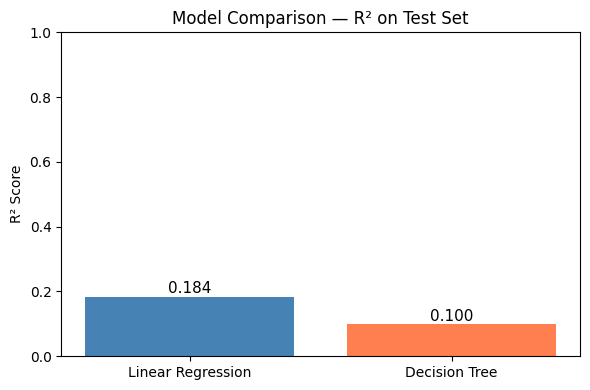

In [18]:
# compare both models side by side
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE':   [lr_mae,  dt_mae],
    'RMSE':  [lr_rmse, dt_rmse],
    'R2':    [lr_r2,   dt_r2]
})
print(results.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

# bar chart comparing R2 scores
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results['Model'], results['R2'], color=['steelblue', 'coral'])
ax.set_ylim(0, 1)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R² on Test Set')
for i, v in enumerate(results['R2']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


We built a pipeline for each model that handles all the preprocessing steps in one shot. The preprocessor is made up of three parts wired together with ColumnTransformer.

For the numeric columns (`bed`, `bath`, `acre_lot`, `house_size`) we used median imputation followed by StandardScaler. Scaling matters for Linear Regression since it's sensitive to the magnitude of features — without it, `house_size` in the thousands would dominate over `bath` which is usually 1-4.

For `status` and `state` we used most_frequent imputation and OneHotEncoder. These only have 3 and 55 unique values respectively so one-hot is fine — the extra columns are manageable.

For `city` and `zip_code` we used TargetEncoder instead of OneHotEncoder. `city` has 20k unique values and `zip_code` has 30k — one-hot encoding those would create 50k+ columns across 2.2M rows which would blow up memory. TargetEncoder replaces each category with the mean price for that category computed from the training data, so it stays as just one column per feature while still capturing the location signal.

Both models ended up with low R² scores — Linear Regression at 0.18 and Decision Tree at 0.11. Linear Regression actually edged out the Decision Tree here. The likely reason for Decision tree to do well could be because of the number of records 2.2M resulting in classic overfitting. The linear regression model scores lower as it misses out on some non linear predictions.

The low R² scores overall aren't too surprising given the state of the data. The price column has extreme outliers going up to $2 billion which completely throws off both models. The data still has heavy skew we could do some outlier capping. A log transform on price and capping the outliers would likely improve both models significantly.


#### Question 6:
Choose two columns of `X_train`, apply differnt feature scaling methods (Standard scalar, MinMax Scalar, Robust Scalar) introduced in Week 1 Jupyter Notebook on them. Compare the data distribution after scaling with original value using visualization.

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# picking house_size and bath_per_bed — one is a raw measurement, one is engineered
# using training data only, fill missing values first so scalers don't choke on NaNs
col1 = 'house_size'
col2 = 'bath_per_bed'

# grab the two columns from training set, drop NaNs for this demo
sample = X_train[[col1, col2]].dropna().copy()

std_scaler    = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

scaled_std    = std_scaler.fit_transform(sample)
scaled_minmax = minmax_scaler.fit_transform(sample)
scaled_robust = robust_scaler.fit_transform(sample)

# put results into dataframes for easy plotting
df_std    = pd.DataFrame(scaled_std,    columns=[col1, col2])
df_minmax = pd.DataFrame(scaled_minmax, columns=[col1, col2])
df_robust = pd.DataFrame(scaled_robust, columns=[col1, col2])

print("Original stats:")
print(sample.describe().to_string(float_format=lambda x: f'{x:,.2f}'))


Original stats:
        house_size  bath_per_bed
count 1,284,477.00  1,284,477.00
mean      2,039.79          0.79
std       4,030.90          0.52
min           4.00          0.01
25%       1,296.00          0.67
50%       1,748.00          0.75
75%       2,400.00          1.00
max   1,560,780.00        460.00


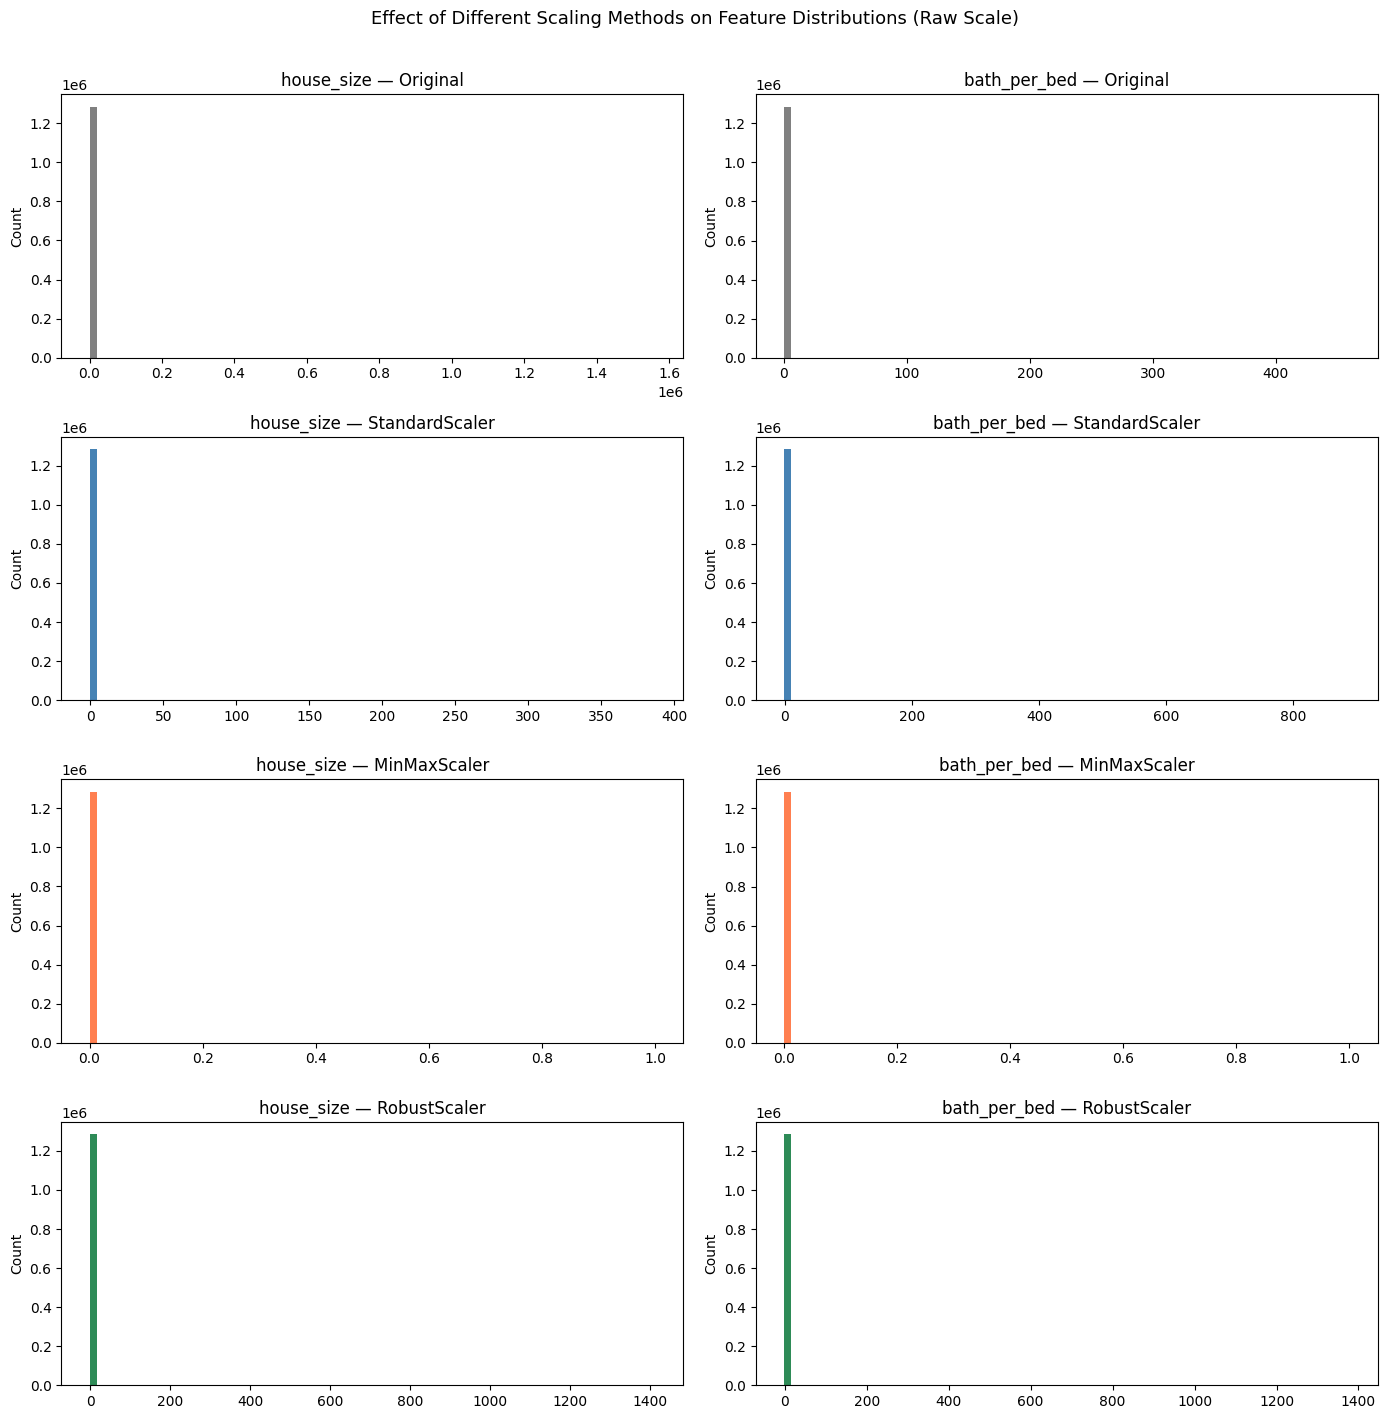

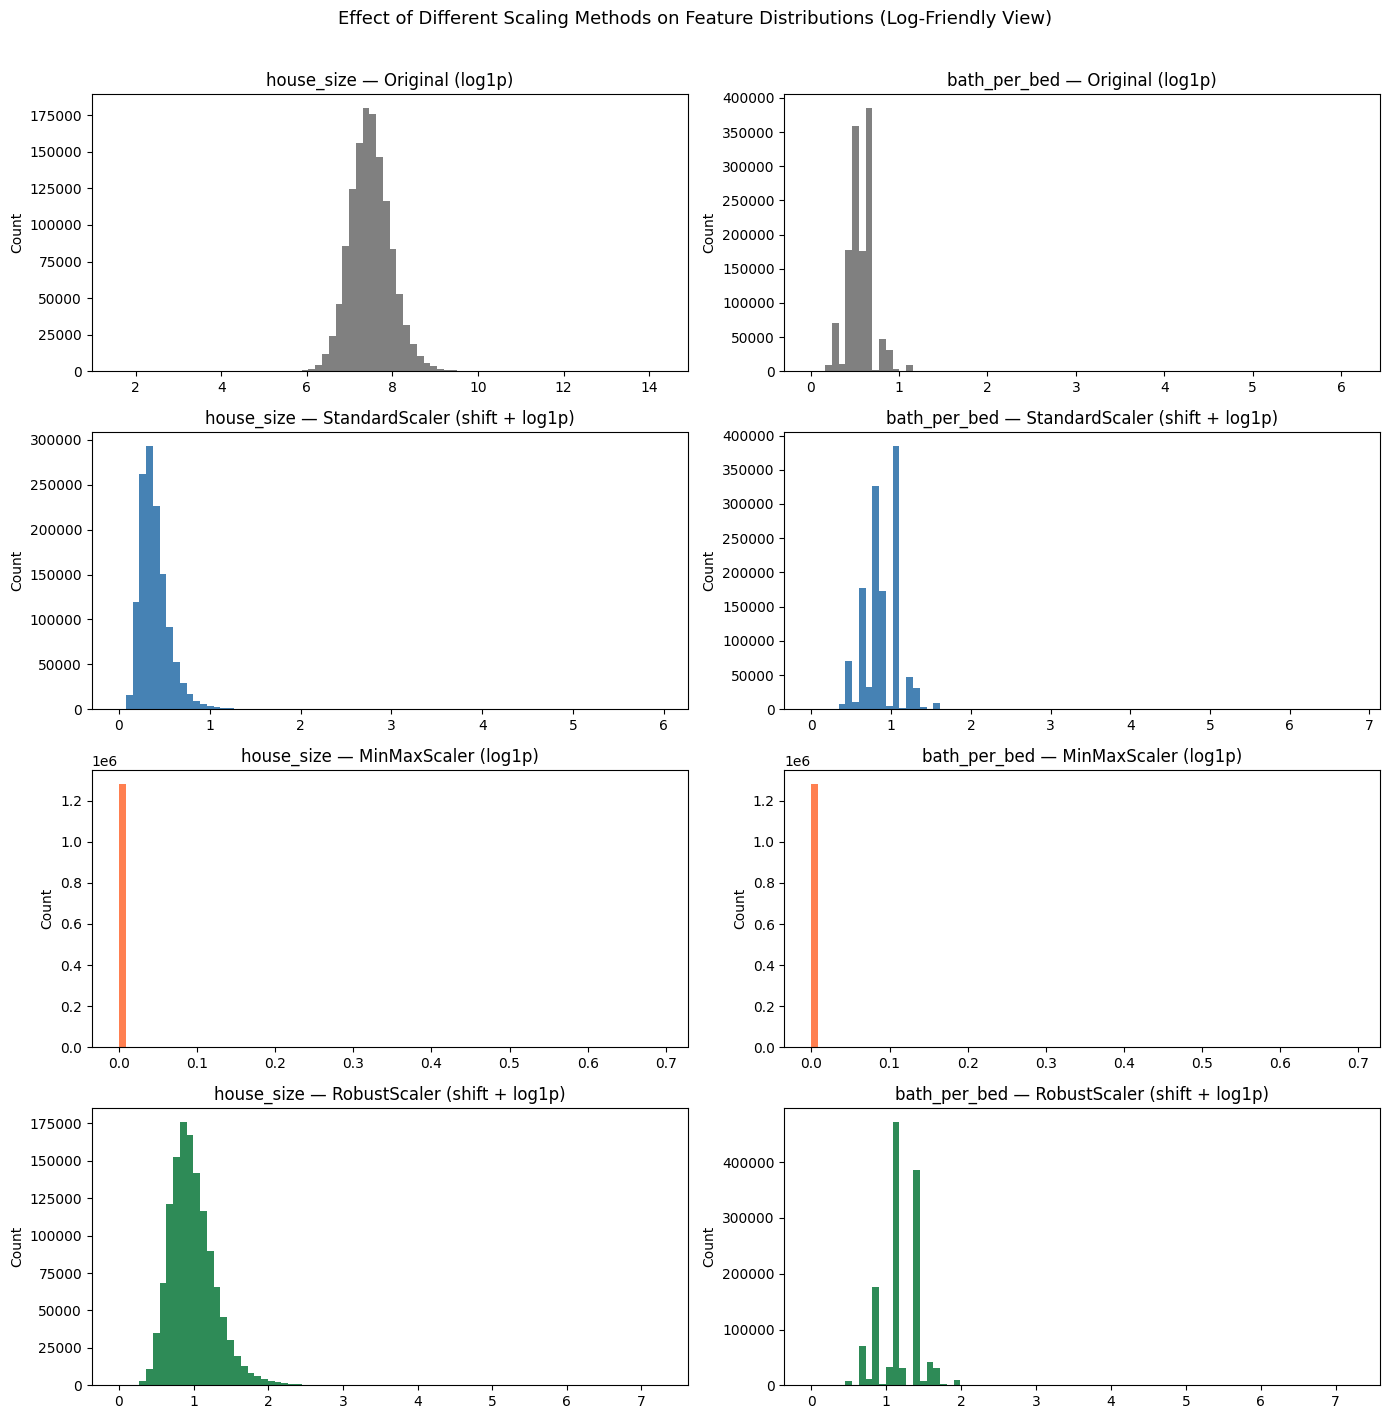

In [22]:
# compare distributions before and after each scaling method
# figure 1: raw scale (can be dominated by extreme outliers)
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for col_idx, col in enumerate([col1, col2]):
    # row 0: original
    axes[0][col_idx].hist(sample[col], bins=80, color='gray', edgecolor='none')
    axes[0][col_idx].set_title(f'{col} — Original')
    axes[0][col_idx].set_ylabel('Count')

    # row 1: StandardScaler — zero mean, unit variance
    axes[1][col_idx].hist(df_std[col], bins=80, color='steelblue', edgecolor='none')
    axes[1][col_idx].set_title(f'{col} — StandardScaler')
    axes[1][col_idx].set_ylabel('Count')

    # row 2: MinMaxScaler — squashes everything into [0, 1]
    axes[2][col_idx].hist(df_minmax[col], bins=80, color='coral', edgecolor='none')
    axes[2][col_idx].set_title(f'{col} — MinMaxScaler')
    axes[2][col_idx].set_ylabel('Count')

    # row 3: RobustScaler — uses median and IQR, less affected by outliers
    axes[3][col_idx].hist(df_robust[col], bins=80, color='seagreen', edgecolor='none')
    axes[3][col_idx].set_title(f'{col} — RobustScaler')
    axes[3][col_idx].set_ylabel('Count')

plt.suptitle('Effect of Different Scaling Methods on Feature Distributions (Raw Scale)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# figure 2: log-friendly view to make skewed distributions readable
# log1p handles zeros safely; clip at 0 to avoid invalid log for any accidental negatives
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for col_idx, col in enumerate([col1, col2]):
    original_log = np.log1p(sample[col].clip(lower=0))
    std_log = np.log1p(df_std[col] - df_std[col].min())
    minmax_log = np.log1p(df_minmax[col])
    robust_log = np.log1p(df_robust[col] - df_robust[col].min())

    axes[0][col_idx].hist(original_log, bins=80, color='gray', edgecolor='none')
    axes[0][col_idx].set_title(f'{col} — Original (log1p)')
    axes[0][col_idx].set_ylabel('Count')

    axes[1][col_idx].hist(std_log, bins=80, color='steelblue', edgecolor='none')
    axes[1][col_idx].set_title(f'{col} — StandardScaler (shift + log1p)')
    axes[1][col_idx].set_ylabel('Count')

    axes[2][col_idx].hist(minmax_log, bins=80, color='coral', edgecolor='none')
    axes[2][col_idx].set_title(f'{col} — MinMaxScaler (log1p)')
    axes[2][col_idx].set_ylabel('Count')

    axes[3][col_idx].hist(robust_log, bins=80, color='seagreen', edgecolor='none')
    axes[3][col_idx].set_title(f'{col} — RobustScaler (shift + log1p)')
    axes[3][col_idx].set_ylabel('Count')

plt.suptitle('Effect of Different Scaling Methods on Feature Distributions (Log-Friendly View)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# side by side stats summary for each scaler
print(f"{'Scaler':<20} {'house_size mean':>18} {'house_size std':>15} {'bath_per_bed mean':>18} {'bath_per_bed std':>16}")
print("-" * 90)

for name, data in [('Original', sample), ('StandardScaler', df_std),
                   ('MinMaxScaler', df_minmax), ('RobustScaler', df_robust)]:
    h_mean = data[col1].mean()
    h_std  = data[col1].std()
    b_mean = data[col2].mean()
    b_std  = data[col2].std()
    print(f"{name:<20} {h_mean:>18.4f} {h_std:>15.4f} {b_mean:>18.4f} {b_std:>16.4f}")


Scaler                  house_size mean  house_size std  bath_per_bed mean bath_per_bed std
------------------------------------------------------------------------------------------
Original                      2039.7894       4030.9034             0.7902           0.5168
StandardScaler                  -0.0000          1.0000            -0.0000           1.0000
MinMaxScaler                     0.0013          0.0026             0.0017           0.0011
RobustScaler                     0.2643          3.6512             0.1207           1.5504


We picked house_size and bath_per_bed for this comparison. house_size is right-skewed with extreme outliers (we saw the max is around 1 billion sq ft), so it's a good stress test for the scalers. bath_per_bed is our engineered feature which is generally less extreme.

StandardScaler subtracts the mean and divides by standard deviation, so every feature ends up centered at 0 with a standard deviation of 1. The shape of the distribution doesn't change — if it was skewed before it's still skewed after. It's the most common choice and works well when features are roughly normally distributed.

MinMaxScaler squashes everything into the range [0, 1]. The problem here is that one extreme outlier in house_size drags everything else down near 0 — the entire normal range of houses gets compressed into a tiny slice of [0, 1]. You can see this in the histogram where almost all values pile up near zero.

RobustScaler uses the median and IQR instead of mean and standard deviation, so it's much less affected by outliers. For house_size this makes a big difference — the bulk of the distribution spreads out more naturally even with the extreme values present. For a dataset like this one with messy outliers, RobustScaler is generally the better choice over StandardScaler or MinMaxScaler.

For the pipeline in Q5 we used StandardScaler, which is reasonable as a baseline. If we were tuning the model further, switching to RobustScaler would likely improve things given how many outliers this dataset has.


In [23]:
# find the record(s) with the maximum price
max_price = df['price'].max()
max_rows = df[df['price'] == max_price].copy()

print(f"Max price: ${max_price:,.0f}")
print(f"Number of rows at max price: {len(max_rows)}")

cols_to_show = [c for c in ['price', 'status', 'bed', 'bath', 'acre_lot', 'house_size', 'city', 'state', 'zip_code', 'street', 'brokered_by'] if c in max_rows.columns]
print(max_rows[cols_to_show].to_string(index=True))

Max price: $2,147,483,600
Number of rows at max price: 1
               price    status  bed  bath  acre_lot  house_size           city       state  zip_code   street  brokered_by
221994  2.147484e+09  for_sale  2.0   2.0      0.12       885.0  International  California       NaN  11355.0      23826.0
